In [1]:
from collections import defaultdict
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

In [2]:
# Load data
folder_path_cold = "../results/cold/ultimatumgame/"
folder_path_ir = "../results/identity_reveal/ultimatumgame/"

def load_data(folder_path):
    data = []
    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.endswith(".json"):
                file_path = os.path.join(root, filename)
                try:
                    with open(file_path, "r") as f:
                        entry = json.load(f)
                        data.append(entry)
                except json.JSONDecodeError as e:
                    print(f"Skipped invalid JSON: {file_path} ({e})")
    
    print(f"Loaded {len(data)} valid JSON result files from '{folder_path}' and its subfolders.")
    return data

data_cold = load_data(folder_path_cold)
data_ir = load_data(folder_path_ir)

Loaded 478 valid JSON result files from '../results/cold/ultimatumgame/' and its subfolders.
Loaded 438 valid JSON result files from '../results/identity_reveal/ultimatumgame/' and its subfolders.


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

def process(data):
    # Set constants
    base_amount = 100
    multiplier = 3
    
    # Create lists to store metrics
    give_data = []
    return_pct_data = []
    
    for entry in data:
        m0 = entry["model_general_name_0"]
        m1 = entry["model_general_name_1"]
    
        sent = int(entry["agent_0_answer"]["amount"])
        received_back = entry["agent_1_answer"]["decision"]
        accept = received_back.lower() == "accept"
    
        give_data.append({
            "sender": m0,
            "receiver": m1,
            "sent_amount": sent
        })
    
        return_pct_data.append({
            "sender": m1,     # agent_1 is now sender in return
            "receiver": m0,
            "accepted_offer": accept
        })
    
    # Convert to DataFrames
    df_give = pd.DataFrame(give_data)
    df_return = pd.DataFrame(return_pct_data)
    
    # Pivot into heatmap format
    heatmap_give = df_give.pivot_table(index="sender", columns="receiver", values="sent_amount", aggfunc="mean")
    heatmap_return = df_return.pivot_table(index="sender", columns="receiver", values="accepted_offer", aggfunc="mean")

    return heatmap_give, heatmap_return

heatmap_give_cold, heatmap_return_cold = process(data_cold)
heatmap_give_ir, heatmap_return_ir = process(data_ir)

In [4]:
def plot_results_trustor(heatmap_give):
    # Plot Heatmap 1 – Amount Sent (agent_0 → agent_1)
    plt.figure(figsize=(8, 6))
    sns.heatmap(heatmap_give, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Amount Sent'}, vmin=0, vmax=100)
    plt.title("Ultimatum Game - Offer Sent")
    plt.ylabel("Trustor (Sender)")
    plt.xlabel("Trustee (Receiver)")
    plt.tight_layout()
    # plt.savefig("4.5-trustor.eps", dpi=300, bbox_inches='tight')
    plt.show()

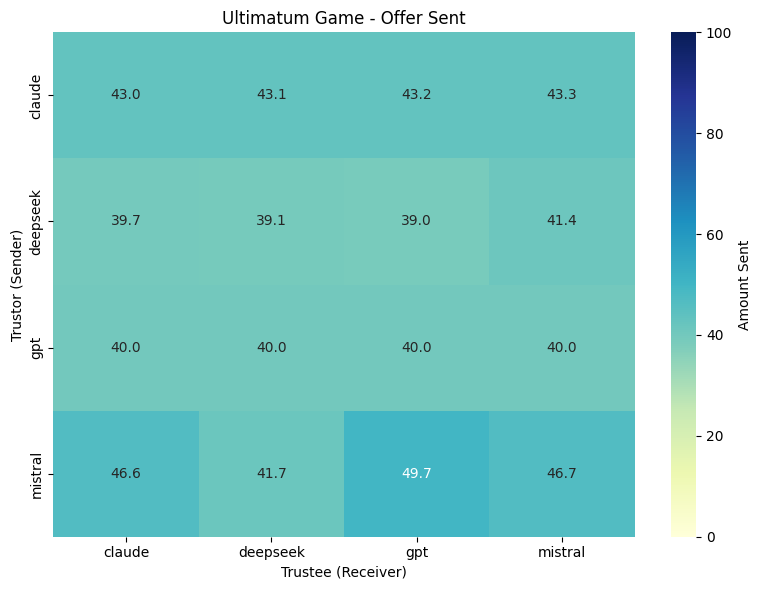

In [5]:
plot_results_trustor(heatmap_give_cold)

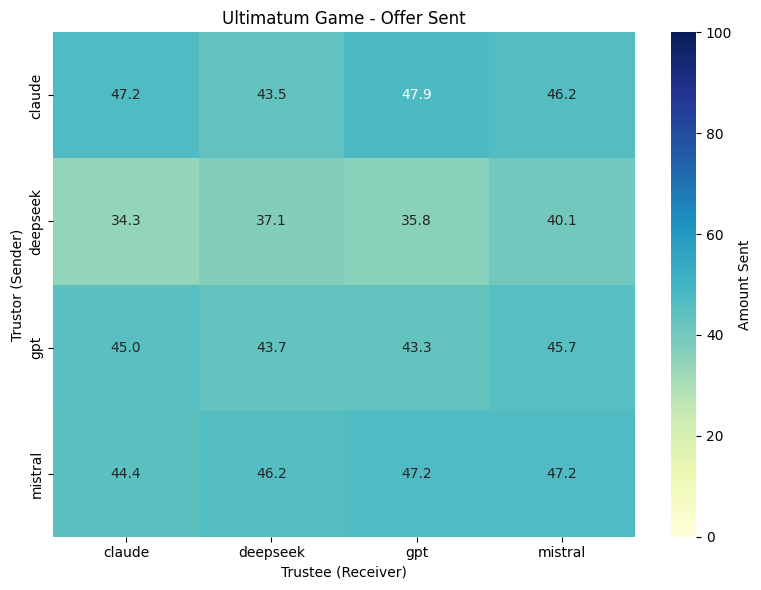

In [6]:
plot_results_trustor(heatmap_give_ir)

In [12]:
# Plot Heatmap 2 – Return Percentage (agent_1 → agent_0)
def plot_results_trustee(heatmap_return):
    plt.figure(figsize=(8, 6))
    sns.heatmap(heatmap_return, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={'label': '% Returned'}, vmin=0, vmax=1)
    plt.title("Trust Game – Trustee - Trustee Returned % of Multiplied Amount")
    plt.ylabel("Trustee (Sender)")
    plt.xlabel("Trustor (Receiver)")
    plt.tight_layout()
    # plt.savefig("4.5-trustee.eps", dpi=300, bbox_inches='tight')
    plt.show()

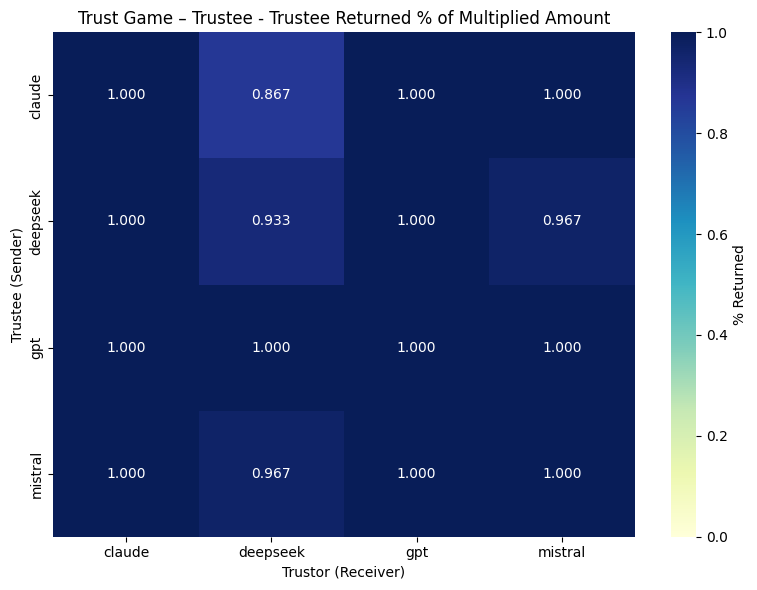

In [13]:
plot_results_trustee(heatmap_return_cold)

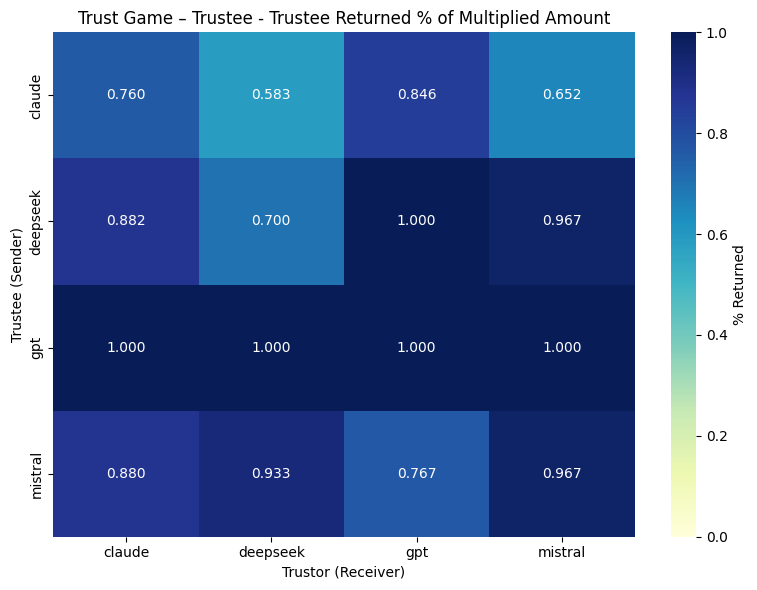

In [14]:
plot_results_trustee(heatmap_return_ir)